In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [2]:
df = pd.read_csv("data/height-weight.csv")
df.head()

,Weight,Height
0,45,120
1,58,135
2,48,123
3,60,145
4,70,160


Text(0, 0.5, 'height')

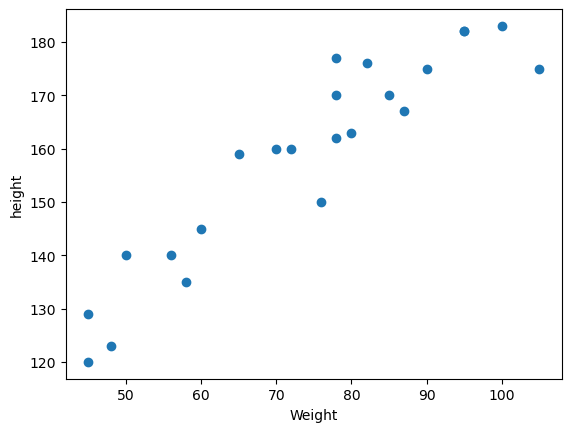

In [3]:
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel("height")

In [4]:
## divide my dataset into independent and dependent
X = df[['Weight']] ## independent features
y = df['Height'] ## dependent features

In [5]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.20,random_state=42)

In [6]:
X.shape

(23, 1)

In [7]:
X_train.shape,X_test.shape

((18, 1), (5, 1))

In [8]:
## standardize the dataset Train independent data
from sklearn.preprocessing import StandardScaler

In [9]:
scaler = StandardScaler()

In [10]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

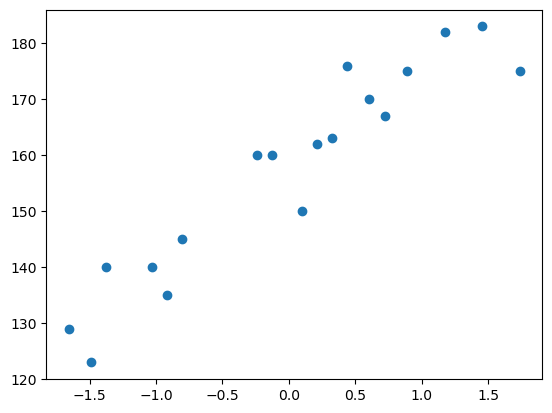

In [11]:
plt.scatter(X_train,y_train)

In [12]:
## Train the simple Linear Regression Model
from sklearn.linear_model import LinearRegression

In [13]:
regressor = LinearRegression()

In [14]:
regressor.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [15]:
print("The slope or coefficient of weight is",regressor.coef_)
print("Intercept",regressor.intercept_)

The slope or coefficient of weight is [17.03440872]
Intercept 157.5


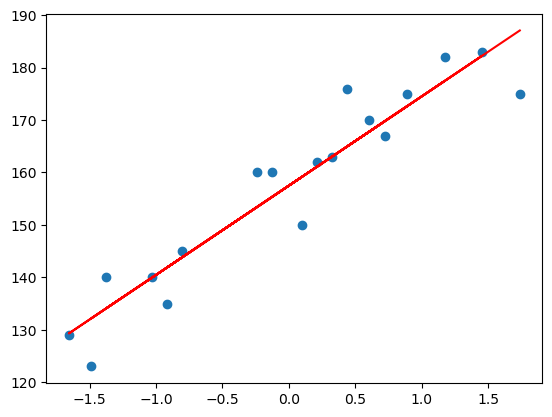

In [16]:
plt.scatter(X_train,y_train)
plt.plot(X_train,regressor.predict(X_train),'r')

# prediction of train data

1. predicted height output = intercept + coef_(Weights)
2. y_pred_train = 157.5 + 17.03(X_train)

# prediction of test data

1. predicted height output = intercept + coef_(Weights)
2. y_pred_test = 157.5 + 17.03(X_test)

In [17]:
y_pred_test = regressor.predict(X_test)

In [18]:
y_pred_test,y_test

(array([161.08467086, 161.08467086, 129.3041561 , 177.45645118,
        148.56507414]),
 15    177
 9     170
 0     120
 8     182
 17    159
 Name: Height, dtype: int64)

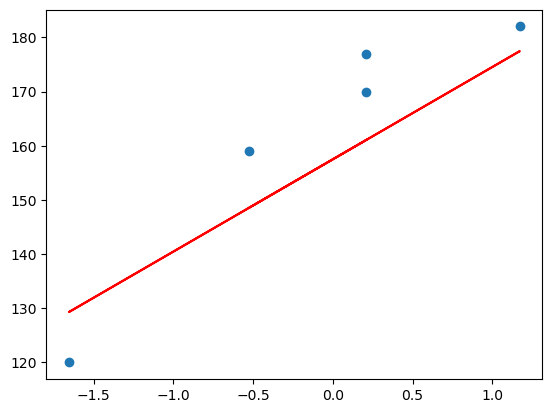

In [19]:
plt.scatter(X_test,y_test)
plt.plot(X_test,regressor.predict(X_test),'r')

# Perforance Metrics

## MSE,MAE,RMSE
## R square and adjusted R square

In [20]:
from sklearn.metrics import mean_squared_error,mean_absolute_error

In [21]:
mse = mean_squared_error(y_test,y_pred_test)
mae = mean_absolute_error(y_test,y_pred_test)
rmse = np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

109.77592599051664
9.822657814519232
10.477400726827081


# R square

formula
R^2 = 1-SSR/SST

R^2 = coefficient of determination SSR = sum of squares of residuals SST = total sum of squares 

In [22]:
from sklearn.metrics import r2_score
score = r2_score(y_test,y_pred_test)

In [23]:
score

0.776986986042344

## Adjusted R Square

**Adjusted R2 = 1 - [(1-R2)*(n-1)/(n-k-1)]**

where 
R2 : The R2 of the model

n : The number of observations

k: The number of predictor vatiables

In [24]:
# display adjusted R-squared
1 - (1-score)*(len(y_test)-1)/(len(y_test)-X_test.shape[1]-1)

0.7026493147231252

In [25]:
## new data point weight is 80
scaled_weight = scaler.transform([[80]])
scaled_weight

g:\anaconda3\envs\rigde_lasso_project\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([[0.32350772]])

In [26]:
print("The height prediction for weight 80 kg is ",regressor.predict([scaled_weight[0]]))

The height prediction for weight 80 kg is  [163.01076266]


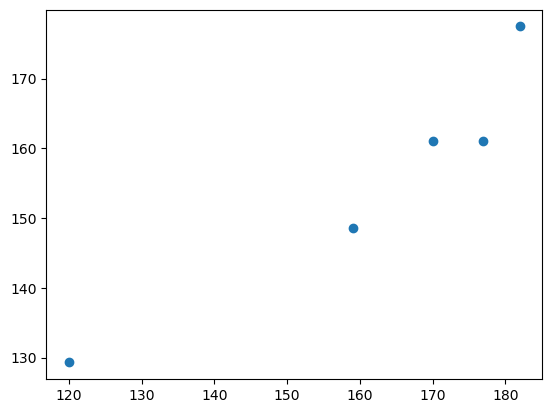

In [27]:
## Assumptions
## Plot a scatter plot for the prediction

plt.scatter(y_test,y_pred_test)

In [28]:
## Residuals
residuals = y_test - y_pred_test
print(residuals)

15    15.915329
9      8.915329
0     -9.304156
8      4.543549
17    10.434926
Name: Height, dtype: float64


C:\Users\Administrator\AppData\Local\Temp\ipykernel_1912\3301513583.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(residuals, kde = True)


<Axes: xlabel='Height', ylabel='Density'>

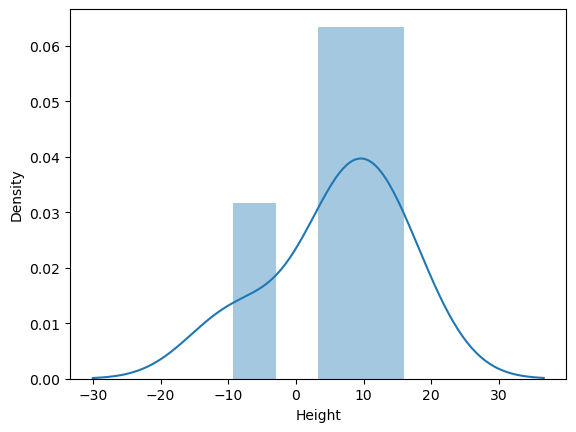

In [29]:
import seaborn as sns
sns.distplot(residuals, kde = True)

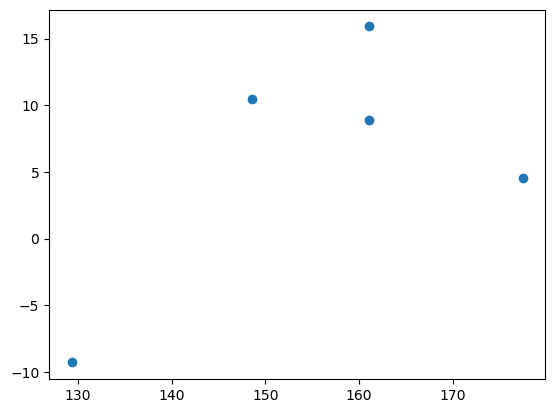

In [30]:
# scatter plot with respect to prediction and residuals
## uniform distribution
plt.scatter(y_pred_test,residuals)